# Student Performance Analysis
**Project 01**

Dataset: *Students Performance in Exams* — 1,000 US high-school students' math, reading and writing scores, along with gender, race/ethnicity group, parental education, lunch type (a proxy for socio-economic status) and whether they completed a test-preparation course.

Goal: load the data, check its quality, describe it, compare groups, visualize it, and state what the numbers actually mean — not just produce charts.

## 1. Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv("StudentsPerformance.csv")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df

Shape: 1000 rows x 8 columns


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [4]:
print("Columns and data types:\n")
print(df.dtypes)

Columns and data types:

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object


**Note:** all three score columns are stored as integers, and the five remaining columns are categorical (`object`) text. There are no ID or timestamp columns — every row is one student's record with no obvious primary key, so duplicate *rows* (not just duplicate scores) are the right thing to check for.

## 2. Data Quality Check

Checking for the three usual suspects: missing values, duplicate rows, and values that fall outside a plausible range (scores should be 0-100).

In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

print(f"\nFully duplicated rows: {df.duplicated().sum()}")

num_cols = ['math score', 'reading score', 'writing score']
print("\nOut-of-range scores (below 0 or above 100):")
for c in num_cols:
    bad = ((df[c] < 0) | (df[c] > 100)).sum()
    print(f"  {c}: {bad} (min={df[c].min()}, max={df[c].max()})")

print("\nCategory labels found (checking for typos / inconsistent casing / stray whitespace):")
for c in ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']:
    print(f"  {c}: {sorted(df[c].unique())}")

Missing values per column:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Total missing cells: 0

Fully duplicated rows: 0

Out-of-range scores (below 0 or above 100):
  math score: 0 (min=0, max=100)
  reading score: 0 (min=17, max=100)
  writing score: 0 (min=10, max=100)

Category labels found (checking for typos / inconsistent casing / stray whitespace):
  gender: ['female', 'male']
  race/ethnicity: ['group A', 'group B', 'group C', 'group D', 'group E']
  parental level of education: ["associate's degree", "bachelor's degree", 'high school', "master's degree", 'some college', 'some high school']
  lunch: ['free/reduced', 'standard']
  test preparation course: ['completed', 'none']


**Finding:** this dataset has **zero missing values, zero duplicate rows, and zero out-of-range scores** - every category column also uses clean, consistent labels with no typos or stray whitespace. Nothing needed to be imputed, dropped or corrected.

This is worth stating explicitly rather than skipping the step: a big part of a real data-quality check is confirming a dataset is *actually* clean before trusting it, not assuming it. This is a well-known, pre-curated teaching dataset, which is exactly why it comes out this clean - a dataset pulled from a live production system almost never would.

The only "cleaning" action taken here is a derived column added for convenience in the analysis below: an `average score` (mean of the three subject scores per student), since several comparisons are easier to read as one overall number per student rather than three separate ones.

In [6]:
df['average score'] = df[num_cols].mean(axis=1)
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,65.000000
998,female,group D,some college,standard,completed,68,78,77,74.333333


## 3. Descriptive Statistics

Mean, median, mode, standard deviation, minimum and maximum for every numeric column.

In [8]:
desc = df[num_cols + ['average score']].agg(['mean', 'median', 'std', 'min', 'max']).T
desc['mode'] = [df[c].mode()[0] for c in num_cols + ['average score']]
desc = desc[['mean', 'median', 'mode', 'std', 'min', 'max']].round(2)
desc

,mean,median,mode,std,min,max
math score,66.09,66.00,65.0,15.16,0.0,100.0
reading score,69.17,70.00,72.0,14.60,17.0,100.0
writing score,68.05,69.00,74.0,15.20,10.0,100.0
average score,67.77,68.33,68.0,14.26,9.0,100.0


**Insight:** the three subjects sit within about 3 points of each other on average (math 66.1, writing 68.1, reading 69.2) - math is the weakest subject overall. All three have a similar spread (std ~ 15 points), and the mean sits just below the median in each case, meaning there are a few low outlier scores (including a math score of 0) pulling the average down slightly - the distribution has a mild left (low-score) tail rather than being perfectly symmetric.

## 4. Group Comparisons

### 4.1 Subject-wise and gender-wise

In [9]:
gender_subject = df.groupby('gender')[num_cols + ['average score']].mean().round(2)
gender_subject

,math score,reading score,writing score,average score
gender,,,,
female,63.63,72.61,72.47,69.57
male,68.73,65.47,63.31,65.84


**Insight:** the subjects split cleanly by gender. Males score higher in math (68.7 vs 63.6) while females score noticeably higher in both reading (72.6 vs 65.5) and writing (72.5 vs 63.3). Because two of the three subjects favor females by a wider margin than math favors males, the overall average score is slightly higher for females (69.6 vs 65.8) - a simple "boys are better at X" or "girls are better at Y" headline would miss that the picture is subject-specific.

### 4.2 By test preparation course

In [10]:
prep = df.groupby('test preparation course')[num_cols + ['average score']].mean().round(2)
prep['count'] = df['test preparation course'].value_counts()
prep

,math score,reading score,writing score,average score,count
test preparation course,,,,,
completed,69.70,73.89,74.42,72.67,358
none,64.08,66.53,64.50,65.04,642


**Insight:** students who completed the test-prep course scored higher in every single subject, with the overall average rising from 65.0 to 72.7 - a 7.6-point gap. Only 358 of the 1,000 students (36%) completed it, so most students in this dataset left that gain on the table. This doesn't prove the course *causes* the improvement (more motivated students may simply be more likely to take it), but the association is consistent and sizeable across all three subjects.

### 4.3 By lunch type (socio-economic proxy)

In [11]:
lunch = df.groupby('lunch')[num_cols + ['average score']].mean().round(2)
lunch['count'] = df['lunch'].value_counts()
lunch

,math score,reading score,writing score,average score,count
lunch,,,,,
free/reduced,58.92,64.65,63.02,62.20,355
standard,70.03,71.65,70.82,70.84,645


**Insight:** this is the largest gap found in the whole dataset. Students on a standard lunch average 70.8 overall versus 62.2 for those on free/reduced lunch - an 8.6-point difference, and it holds in every subject. Since lunch assistance is generally tied to household income, this reads as the clearest socio-economic signal in the data - bigger than the gender gap and bigger than the test-prep gap.

### 4.4 By parental level of education

In [12]:
parent_edu_order = df.groupby('parental level of education')['average score'].mean().sort_values(ascending=False)
parent_edu = df.groupby('parental level of education')[num_cols + ['average score']].mean().reindex(parent_edu_order.index).round(2)
parent_edu

,math score,reading score,writing score,average score
parental level of education,,,,
master's degree,69.75,75.37,75.68,73.60
bachelor's degree,69.39,73.00,73.38,71.92
associate's degree,67.88,70.93,69.90,69.57
some college,67.13,69.46,68.84,68.48
some high school,63.50,66.94,64.89,65.11
high school,62.14,64.70,62.45,63.10


**Insight:** there's a fairly steady climb from "some high school" / "high school" parents (63-65 average) up to "master's degree" parents (73.6) - a 10.5-point spread from lowest to highest, the widest gradient of any segment examined. It isn't a hard cutoff, though: "associate's degree" (69.6) and "some college" (68.5) sit close together in the middle, so the effect looks more like a gradual slope than two distinct tiers.

## 5. Visual Insights

Five required chart types (bar, pie, histogram, box plot, scatter) plus a correlation heatmap, each followed by a short written interpretation.

### Chart 1 - Bar chart: average score by subject, split by gender

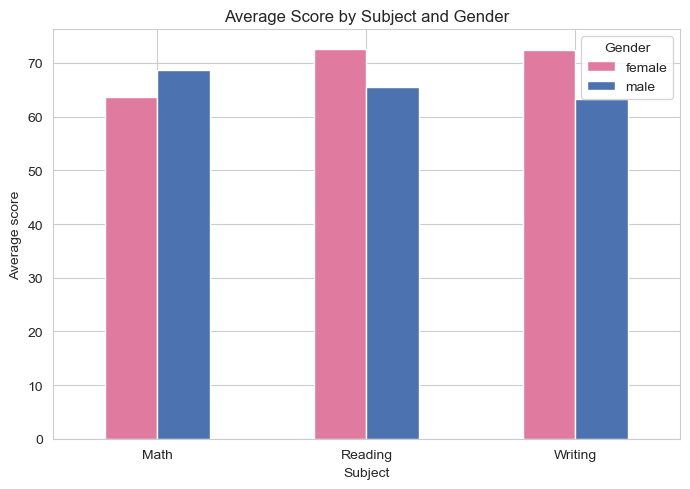

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
gender_subject[num_cols].T.plot(kind='bar', ax=ax, color=['#e07a9e', '#4c72b0'])
ax.set_ylabel('Average score')
ax.set_xlabel('Subject')
ax.set_title('Average Score by Subject and Gender')
ax.set_xticklabels(['Math', 'Reading', 'Writing'], rotation=0)
ax.legend(title='Gender')
plt.tight_layout()
plt.show()

**What it shows:** math is the only subject where males lead; reading and writing both favor females, and by a wider margin than math favors males. The crossover pattern is the main thing to notice - it's not a uniform "one gender does better overall," it's subject-dependent.

### Chart 2 - Bar chart: average score by parental education level

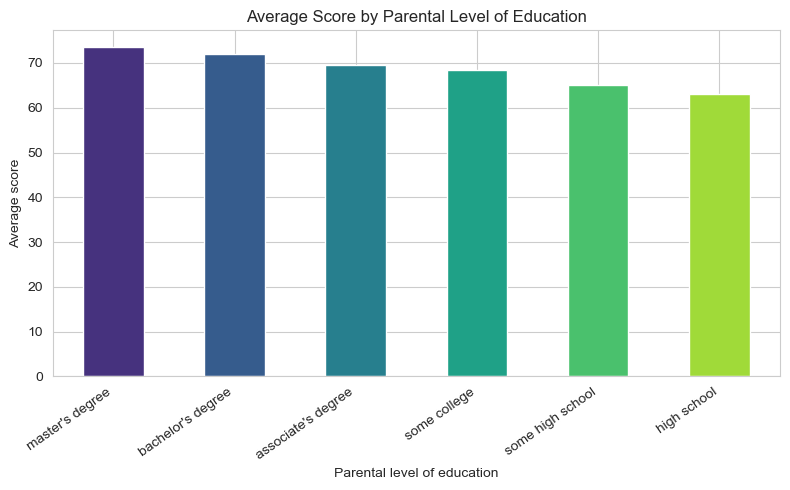

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette('viridis', len(parent_edu_order))
parent_edu_order.plot(kind='bar', ax=ax, color=colors)
ax.set_ylabel('Average score')
ax.set_xlabel('Parental level of education')
ax.set_title('Average Score by Parental Level of Education')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

**What it shows:** average score rises fairly steadily as parental education increases, from about 63 for "high school" parents to about 74 for "master's degree" parents. The line isn't perfectly monotonic (associate's and some-college are close together), but the overall direction is clear and it's the widest gap of any segment in this dataset.

### Chart 3 - Pie chart: test preparation course completion

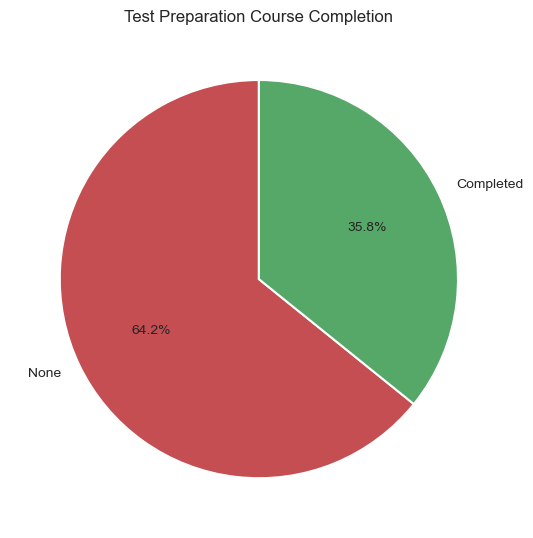

In [16]:
counts = df['test preparation course'].value_counts()
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.pie(counts, labels=[l.title() for l in counts.index], autopct='%1.1f%%',
       colors=['#c44e52', '#55a868'], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Test Preparation Course Completion')
plt.tight_layout()
plt.show()

**What it shows:** only 35.8% of students completed the test-prep course; the majority (64.2%) did not. Combined with the earlier finding that completers scored about 7.6 points higher on average, this means most of the sample never took the one intervention in this dataset associated with a measurable score gain.

### Chart 4 - Histogram: distribution of average score

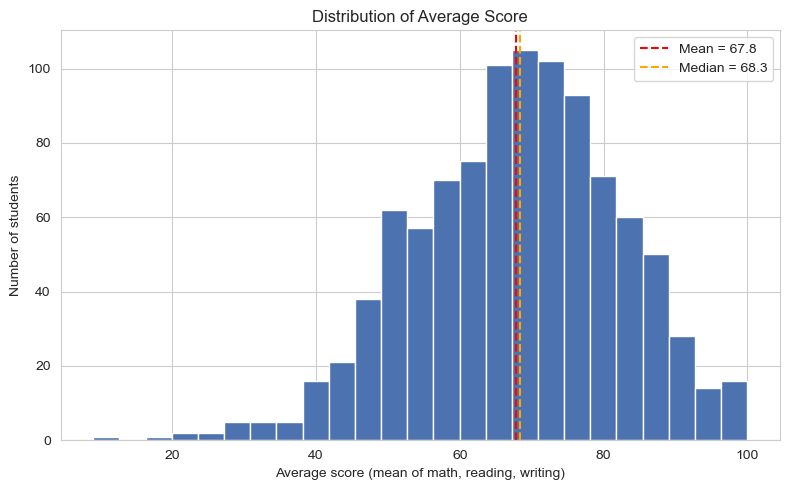

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['average score'], bins=25, color='#4c72b0', edgecolor='white')
ax.axvline(df['average score'].mean(), color='red', linestyle='--', label=f"Mean = {df['average score'].mean():.1f}")
ax.axvline(df['average score'].median(), color='orange', linestyle='--', label=f"Median = {df['average score'].median():.1f}")
ax.set_xlabel('Average score (mean of math, reading, writing)')
ax.set_ylabel('Number of students')
ax.set_title('Distribution of Average Score')
ax.legend()
plt.tight_layout()
plt.show()

**What it shows:** the distribution is roughly bell-shaped and centered in the high-60s, which is what you'd expect from an average of three moderately-correlated exam scores. The mean sits just under the median, confirming the mild low-score tail noted earlier (a handful of students scoring well below 40) - but the bulk of students cluster between 55 and 80.

### Chart 5 - Box plot: average score by lunch type

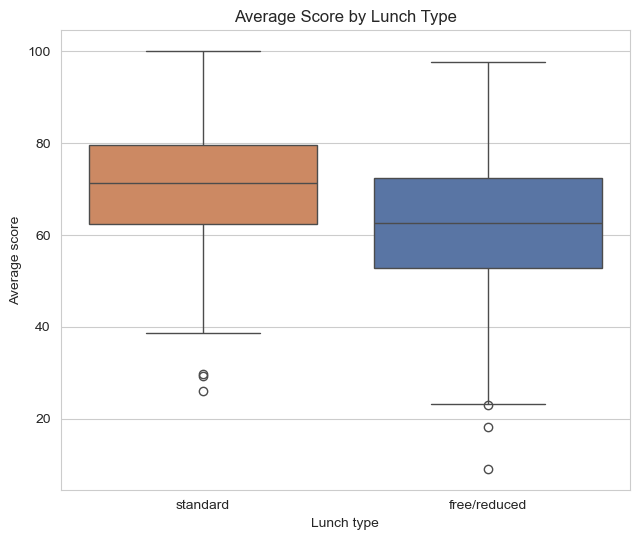

In [18]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.boxplot(data=df, x='lunch', y='average score', ax=ax, hue='lunch', palette=['#dd8452', '#4c72b0'], legend=False)
ax.set_title('Average Score by Lunch Type')
ax.set_xlabel('Lunch type')
ax.set_ylabel('Average score')
plt.tight_layout()
plt.show()

**What it shows:** not only is the median clearly higher for the standard-lunch group, the whole box (and the bottom whisker) sits higher too - free/reduced-lunch students are more likely to have low scores, not just a lower average. The two groups' interquartile ranges barely overlap at the low end, which is a stronger signal than the gap in means alone suggests.

### Chart 6 - Scatter plot: reading score vs. writing score

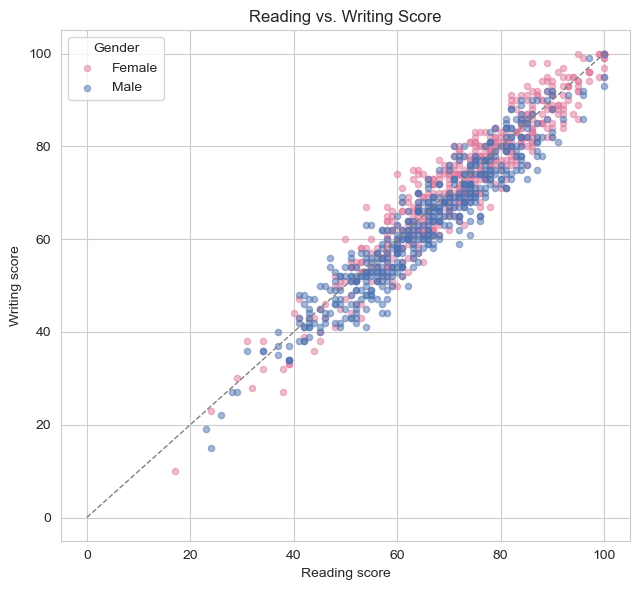

In [19]:
fig, ax = plt.subplots(figsize=(6.5, 6))
colors_map = {'female': '#e07a9e', 'male': '#4c72b0'}
for g, sub in df.groupby('gender'):
    ax.scatter(sub['reading score'], sub['writing score'], alpha=0.5, s=20, label=g.title(), color=colors_map[g])
ax.plot([0, 100], [0, 100], color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Reading score')
ax.set_ylabel('Writing score')
ax.set_title('Reading vs. Writing Score')
ax.legend(title='Gender')
plt.tight_layout()
plt.show()

**What it shows:** the points sit tightly along the diagonal - a student's reading and writing scores are almost always close to each other, regardless of gender. This is a visual preview of the very strong correlation (r ~ 0.955) confirmed in the next section: reading and writing behave almost like the same underlying skill rather than two independent ones.

## 6. Correlation Check

In [20]:
corr = df[num_cols].corr().round(3)
corr

,math score,reading score,writing score
math score,1.000,0.818,0.803
reading score,0.818,1.000,0.955
writing score,0.803,0.955,1.000


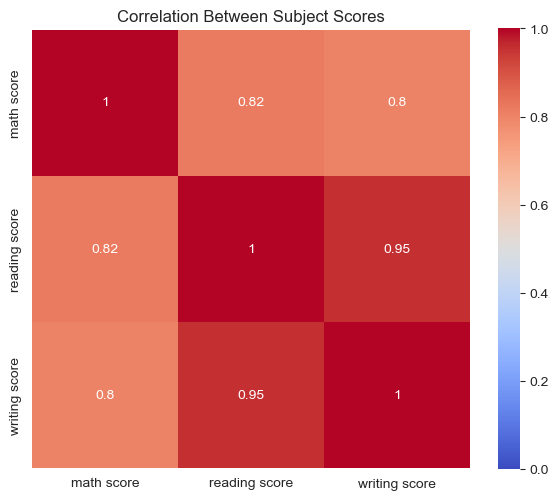

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=0, vmax=1, square=True, ax=ax)
ax.set_title('Correlation Between Subject Scores')
plt.tight_layout()
plt.show()

**What it shows:** reading and writing are very strongly correlated (r = 0.955) - a student rarely does well in one and poorly in the other. Math correlates moderately with both (r = 0.818 with reading, r = 0.803 with writing) - related, since all three demand general academic ability, but clearly a more distinct skill than reading and writing are from each other. Practically, this suggests writing and reading scores carry a lot of the same information, while math measures something meaningfully separate.

## 7. Conclusion - Top 5 Findings

1. **Socio-economic status (lunch type) shows the single largest score gap in the dataset.** Standard-lunch students average 70.8 vs. 62.2 for free/reduced-lunch students - an 8.6-point gap that holds across every subject and shifts the whole score distribution upward, not just the average.

2. **Parental education has the widest gradient of any segment (10.5 points),** climbing steadily from "high school" parents (~63) to "master's degree" parents (~74), though the middle categories (associate's/some college) overlap rather than forming sharp tiers.

3. **Test-prep completion is associated with a consistent ~7.6-point gain across all three subjects, but only 36% of students took it** - the one factor here that looks actionable (unlike gender or lunch) is the one most students didn't use.

4. **Gender effects are subject-specific, not uniform.** Males lead in math (+5.1); females lead more strongly in reading (+7.1) and writing (+9.2) - so the overall average still favors females, but a single "who's better" headline would misrepresent the math result.

5. **Reading and writing scores are near-duplicates of each other (r = 0.955), while math is a more independent skill (r ~ 0.80-0.82 with the other two).** For any future modeling on this data, reading and writing would carry largely redundant information.

**Data quality note:** the dataset itself required no cleaning - no missing values, no duplicate rows, and no out-of-range scores were found. The only preparation step was adding a derived `average score` column to simplify group comparisons.